In [61]:
import os
from dotenv import load_dotenv
load_dotenv()
from langchain.chat_models import init_chat_model
from langchain_groq import ChatGroq

os.environ["GROQ_API_KEY"]= os.getenv("GROQ_API_KEY")
model = ChatGroq(
    model="openai/gpt-oss-20b",
    temperature=0
)

os.environ["TAVILY_API_KEY"]= os.getenv("TAVILY_API_KEY")

### Input Context -> SystemPrompt

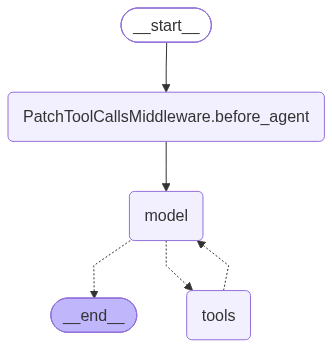

In [2]:
from deepagents import create_deep_agent

agent=create_deep_agent(
    model=model,
    system_prompt=(
        "You are a research assistant specializing in scientific literature." \
        "Always cite sources. Use subagents for paralel research on different topics."
    ),
)

agent  

In [3]:
result=agent.invoke({"messages": [{"role":"user","content":"What is deep agent?"}]})
print(result["messages"][-1].content) 

**Deep Agent – a quick primer**

| What it is | Typical use‑cases | Key papers / resources |
|------------|------------------|------------------------|
| **A reinforcement‑learning (RL) agent that uses deep neural networks** to represent its policy, value function, or model of the environment. | • Playing Atari games from raw pixels (DQN) <br>• Mastering board games (AlphaGo, AlphaZero) <br>• Autonomous driving, robotics, and any task that requires perception from high‑dimensional sensory data | • Mnih et al., “Human‑level control through deep reinforcement learning,” *Nature* 2015. <br>• Silver et al., “Mastering the game of Go with deep neural networks and tree search,” *Nature* 2016. <br>• Li et al., “Deep Reinforcement Learning: A Brief Survey,” *IEEE Transactions on Neural Networks and Learning Systems* 2019. |

---

### 1.  What is a “deep” agent?

A *deep agent* is an RL agent that replaces the hand‑crafted or tabular function approximators of classic RL with **deep neural netwo

In [4]:
from pathlib import Path
agentsmd=Path("projects/AGENTS.md").read_text(encoding="utf-8")
agentsmd

'# AGENTS.md\n\nThis file gives AI coding agents (Claude Code, Cursor, Codex, etc.) the context\nthey need to work effectively in this repository. It documents the **Deep\nAgents** architecture pattern used here: long-horizon, tool-using agents built\nfrom four core pieces — a planning tool, a virtual file system, sub-agents,\nand a detailed system prompt.\n\n## Project Overview\n\nA "deep agent" is an LLM agent designed to handle complex, multi-step tasks\nreliably over long horizons (research, coding, large edits) rather than\nsingle-shot Q&A. It borrows the pattern used by Claude Code, Deep Research,\nand Manus: instead of relying on the model to hold everything in its head,\nthe harness gives it explicit scaffolding for planning, memory, and\ndelegation.\n\nThe four pillars:\n\n1. **Planning tool** — an explicit `write_todos` / task-list tool the agent\n   uses to externalize its plan before acting, and update as it progresses.\n2. **Virtual file system** — `ls`, `read_file`, `writ

# Backends

In [14]:
from langgraph.checkpoint.memory import MemorySaver   
agent=create_deep_agent(
    model=model,
    checkpointer=MemorySaver(),#no memory,no file,no backends
)
result=agent.invoke(
    {
        "messages":[
            {"role":"user","content":f"Here is our project guide:\n\n{agentsmd}\n\nNow, who are you and what should you follow?"}
        ]
    },
    config={"configurable":{"thread_id":"default-demo-1"}}, #fresh thread => memory loads

)
print(result['messages'][-1].content)
#but with bakends filesystem or state or store backends we could have a perfect storage for the agentmd file

I’m a **Deep Agent** – an LLM‑powered coding assistant built on the pattern described in `AGENTS.md`.  
In practice that means:

| What I am | What I do |
|-----------|-----------|
| **Planning‑oriented** | I must write a todo list (`write_todos`) before tackling any multi‑step task, keep only one item `in_progress`, and rewrite the full list on each update. |
| **File‑aware** | I use the virtual file‑system tools (`ls`, `read_file`, `write_file`, `edit_file`, `glob`, `grep`) to persist large artifacts, read them back later, and keep the model’s context small. |
| **Sub‑agent‑friendly** | I can spawn context‑quarantined sub‑agents via the `task` tool when a chunk of work would pollute the parent’s context or needs a different prompt/model. Sub‑agents return only a summary. |
| **Prompt‑driven** | I follow the detailed system prompt that specifies when to plan, when to delegate, and the exact output format. |
| **Safe & deterministic** | I read before editing, avoid destructive ops unle

In [21]:
agent=create_deep_agent(
    model=model,
    memory=["project/AGENTS.md"],
    checkpointer=MemorySaver()
)

In [22]:
from deepagents.backends.utils import create_file_data
create_file_data(agentsmd)

{'content': '# AGENTS.md\n\nThis file gives AI coding agents (Claude Code, Cursor, Codex, etc.) the context\nthey need to work effectively in this repository. It documents the **Deep\nAgents** architecture pattern used here: long-horizon, tool-using agents built\nfrom four core pieces — a planning tool, a virtual file system, sub-agents,\nand a detailed system prompt.\n\n## Project Overview\n\nA "deep agent" is an LLM agent designed to handle complex, multi-step tasks\nreliably over long horizons (research, coding, large edits) rather than\nsingle-shot Q&A. It borrows the pattern used by Claude Code, Deep Research,\nand Manus: instead of relying on the model to hold everything in its head,\nthe harness gives it explicit scaffolding for planning, memory, and\ndelegation.\n\nThe four pillars:\n\n1. **Planning tool** — an explicit `write_todos` / task-list tool the agent\n   uses to externalize its plan before acting, and update as it progresses.\n2. **Virtual file system** — `ls`, `read_

In [23]:
result=agent.invoke(
    {
        "messages":[{"role":"user","content":"What's in your memory? Who are you from the file we provided?"}],
        "files":{"/projects/AGENTS.md":create_file_data(agentsmd)},
    },
    config={"configurable":{"thread_id":"default-demo-1"}},
)
print(result["messages"][-1].content)

I don’t have any persistent memory loaded at the moment—my `<agent_memory>` is empty.  
I’m ChatGPT, a large language‑model trained by OpenAI, and I don’t have any personal or user‑specific information stored unless you explicitly give me something to remember. If you’d like me to load or reference a particular file, just let me know!


In [25]:
from deepagents import create_deep_agent
from deepagents.backends import CompositeBackend, StateBackend, StoreBackend
from deepagents.backends.utils import create_file_data
from langgraph.store.memory import InMemoryStore
from langgraph.checkpoint.memory import MemorySaver

store = InMemoryStore()
store.put(
    ("project",),                  # this one IS a literal tuple — store.put's raw API
    "/memories/AGENTS.md",
    create_file_data(agentsmd),
)

agent = create_deep_agent(
    model=model,
    memory=["/memories/AGENTS.md"],
    backend=CompositeBackend(
        default=StateBackend(),
        routes={
            "/memories/": StoreBackend(
                namespace=lambda rt: ("project",),   # <-- must be callable
            ),
        },
    ),
    store=store,
    checkpointer=MemorySaver(),
)

result = agent.invoke(
    {"messages": [{"role": "user", "content": "What's in your memory? Who are you from the file we provided?"}]},
    config={"configurable": {"thread_id": "default-demo-1"}},
)
print(result["messages"][-1].content)

I don’t have any persistent memory loaded at the moment—my `<agent_memory>` is empty.  
I’m ChatGPT, a large language‑model trained by OpenAI, and I don’t have any personal or user‑specific information stored unless you explicitly give me something to remember. If you’d like me to load or reference a particular file, just let me know!


In [ ]:
# --- StoreBackend: persistent, cross-thread memory ---
# WHY: files/memory live in a LangGraph BaseStore, NOT in one conversation's state.
# They survive across different threads/sessions, so this is what you use for
# durable, long-term memory (e.g. per-user preferences the agent should recall
# next week). Here InMemoryStore is used for the demo; swap in a persistent store
# (e.g. Postgres) for real persistence.
from deepagents import create_deep_agent
from deepagents.backends.store import StoreBackend
from langgraph.store.memory import InMemoryStore
from langgraph.checkpoint.memory import MemorySaver

store = InMemoryStore()
# Seed durable memory into the store once. Namespace + key identify the file.
store.put(("memories",), "AGENTS.md", create_file_data(agentsmd))

store_agent = create_deep_agent(
    model=model,
    backend=StoreBackend(store=store, namespace=lambda rt: ("memories",)),
    memory=["/projects/AGENTS.md"],            # read from the store, not state or disk
    store=store,
    checkpointer=MemorySaver(),
)
# lambda rt: — StoreBackend requires a function, not a static value,
# because it needs to support per-user/per-request namespaces (rt = runtime, could give you rt.context.user_id). You're not using that here,
# but the interface still requires a callable — so you write a lambda that ignores rt and just returns a fixed value.
# ("memories",) — that comma makes it a tuple with one element. Without the comma, ("memories") is just the string "memories" in parens — not a tuple.
# Namespaces must be tuples (so they can support multiple nested levels like ("users","alice")), so the trailing comma is required syntax, not a typo.

result = store_agent.invoke(
    {"messages": [{"role": "user", "content": "What's in your memory? Who are you?"}]},
    config={"configurable": {"thread_id": "store-demo-1"}},
)
print(result["messages"][-1].content)

# /memories/AGENTS.md          → namespace ("memories",),  key "AGENTS.md"
# /users/alice/preferences.md  → namespace ("users","alice"), key "preferences.md"
# /users/bob/preferences.md    → namespace ("users","bob"),   key "preferences.md"

I’m an AI assistant built on the OpenAI GPT‑4 architecture. I don’t have personal memories or experiences of my own—my “memory” is just the data that’s been loaded into me when I start up. In this session, the `<agent_memory>` block is empty, so I don’t have any pre‑existing notes or context from previous interactions.

I can, however, store new information for future use by writing to files on the system (via the `edit_file` tool) or by saving user‑provided preferences. If you’d like me to remember something (e.g., a preference, a piece of data, or a task), just let me know and I’ll add it to the appropriate file.


In [32]:
result

{'messages': [HumanMessage(content="What's in your memory? Who are you?", additional_kwargs={}, response_metadata={}, id='6a289d22-f66d-431c-b7dd-2879700be7b7'),
  AIMessage(content='I’m an AI assistant built on the OpenAI GPT‑4 architecture. I don’t have personal memories or experiences of my own—my “memory” is just the data that’s been loaded into me when I start up. In this session, the `<agent_memory>` block is empty, so I don’t have any pre‑existing notes or context from previous interactions.\n\nI can, however, store new information for future use by writing to files on the system (via the `edit_file` tool) or by saving user‑provided preferences. If you’d like me to remember something (e.g., a preference, a piece of data, or a task), just let me know and I’ll add it to the appropriate file.', additional_kwargs={'reasoning_content': 'The user asks: "What\'s in your memory? Who are you?" We need to respond. According to guidelines, we should not reveal internal memory content beyon

In [33]:
# --- FilesystemBackend: read files/memory straight from DISK ---
# WHY: the agent's files and memory map to real files on disk under root_dir.
# Nothing to seed — if AGENTS.md exists on disk, memory just loads it. Best for
# project context (AGENTS.md, docs, code) that already lives in your repo.
from deepagents import create_deep_agent
from deepagents.backends.filesystem import FilesystemBackend
from langgraph.checkpoint.memory import MemorySaver

# root_dir = the projects/ folder, so paths are resolved relative to it.
# AGENTS.md sits directly inside projects/, so the memory path is just "AGENTS.md".
# virtual_mode=True confines the agent to root_dir (blocks '..' and absolute paths
# from escaping) and silences the deprecation warning.
fs_agent = create_deep_agent(
    model=model,
    backend=FilesystemBackend(root_dir="projects", virtual_mode=True),
    memory=["AGENTS.md"],                             # -> projects/AGENTS.md
    checkpointer=MemorySaver(),
)

# Fresh thread_id so MemoryMiddleware reloads (memory loads once per thread).
result = fs_agent.invoke(
    {"messages": [{"role": "user", "content": "What's in your memory? Who are you?"}]},
    config={"configurable": {"thread_id": "fs-demo-2"}},
)
print(result["messages"][-1].content)

I’m an AI assistant built on the “Deep Agents” architecture.  
In my memory I have:

* The overall layout of the repository (the `src/agents`, `src/tools`, `src/subagents`, etc. directories).  
* The list of tools I can call (file‑system helpers, a planning tool, a sub‑agent launcher, etc.).  
* The high‑level design principles and guidelines that govern how I should plan, use tools, and keep the conversation concise.

I don’t retain any private or sensitive data, and I don’t reveal the exact text of the files I’ve loaded.  If you’d like to see a specific file or explore the repository, just let me know!


In [34]:
result = fs_agent.invoke(
    {"messages": [{"role": "user", "content": "What is LLM Gateways?"}]},
    config={"configurable": {"thread_id": "fs-demo-2"}},
)
print(result["messages"][-1].content)

**LLM Gateways** is a general‑purpose pattern (not a file in this repo) that describes a lightweight “router” or “proxy” layer that sits between a client (e.g., a user, a web app, or another service) and one or more large language models (LLMs).  
The gateway’s job is to:

| Function | What it does |
|----------|--------------|
| **Model selection** | Pick the most appropriate LLM for a given request (e.g., a cheaper model for quick fact‑checking, a more powerful model for creative writing). |
| **Prompt templating** | Apply a consistent prompt template or system prompt before forwarding the user’s text to the LLM. |
| **Rate‑limiting & cost control** | Enforce quotas, throttle requests, or split a single request into smaller chunks to stay within token limits. |
| **Post‑processing** | Clean up the raw LLM output (strip markdown, remove unwanted tags, format JSON, etc.) before returning it to the caller. |
| **Logging & analytics** | Record request/response metadata for monitoring, de

Quick breakdown — three different "memory" things, easy to conflate:

**1. `MemorySaver` (checkpointer)**
- Persists **conversation/graph state** across multiple `.invoke()` calls on the same `thread_id`.
- Scope: one thread. Ask again later with the same `thread_id` → it remembers messages, files in state, etc.
- Storage: in Python process RAM only — gone when the process restarts. ("Memory" here just means RAM, not "the agent's memory.")

**2. `StateBackend`**
- Where **files** live by default when using deepagents' filesystem tools.
- Scope: ephemeral, tied to one thread's graph state — same lifetime as whatever checkpointer you use. If you use `MemorySaver`, files survive across turns in that thread; if no checkpointer, they vanish after one `.invoke()`.
- Not shared across threads/users.

**3. `StoreBackend` (backed by a LangGraph `BaseStore`, e.g. `InMemoryStore`)**
- **Cross-thread, cross-session** persistent storage, addressed by `namespace + key`.
- Scope: whatever you make it — global, per-user, per-org — via the `namespace` function.
- This is what `memory=[...]` typically routes to for "the agent remembers this forever/across conversations" behavior.

**One-line summary:**
- `MemorySaver` = remembers the *conversation* (per thread).
- `StateBackend` = remembers *files*, but only as long as the thread/checkpointer does.
- `StoreBackend` = remembers *files/data* forever, across threads and users, keyed by namespace.

# SKILLS

In [42]:
from urllib.request import urlopen
from deepagents import create_deep_agent
from deepagents.backends import StateBackend
from deepagents.backends.utils import create_file_data
from langchain_quickjs import CodeInterpreterMiddleware

checkpointer=MemorySaver()
backend=StateBackend

from pathlib import Path
skills_content=Path("skills/langgraph/SKILL.md").read_text(encoding="utf-8")

skills_files={
    "/skills/langgraph/SKILLS.md":create_file_data(skills_content),
}

In [43]:
#read every skills
skill_dirs=["langgraph","python","aws","report"]
skills_files={
    f"/skills/{name}/SKILL.md":create_file_data(
        Path(f"skills/{name}/SKILL.md").read_text(encoding="utf-8")
    )
    for name in skill_dirs
}
skills_files

{'/skills/langgraph/SKILL.md': {'content': '---\nname: langgraph\ndescription: Use when a Deep Agent request involves LangGraph, deepagents, StateGraph, state schemas, nodes, edges, tools, subagents, middleware, checkpointers, stores, backends, streaming, or human-in-the-loop workflows.\nuser-invocable: false\n---\n\n# LangGraph Skill\n\nDesign, implement, debug, and review reliable LangGraph and Deep Agents workflows. Treat the graph as a durable, observable state machine rather than a prompt with incidental control flow.\n\n## Model the Workflow\n\nBefore editing, write down:\n\n- State fields, types, ownership, reducers, defaults, and which fields may contain sensitive data.\n- Entry point, node responsibilities, conditional routes, terminal conditions, retry boundaries, and human approval points.\n- External side effects, idempotency keys, timeouts, compensation behavior, and what can safely be replayed.\n- Thread identity, tenant identity, checkpoint policy, durable-store namespac

In [74]:
import requests, os

resp = requests.get(
    "https://api.groq.com/openai/v1/models",
    headers={"Authorization": f"Bearer {os.environ['GROQ_API_KEY']}"},
)
for m in resp.json()["data"]:
    print(m["id"])

meta-llama/llama-prompt-guard-2-86m
whisper-large-v3-turbo
whisper-large-v3
canopylabs/orpheus-arabic-saudi
openai/gpt-oss-safeguard-20b
groq/compound-mini
qwen/qwen3.8-27b
allam-2-7b
canopylabs/orpheus-v1-english
groq/compound
openai/gpt-oss-20b
meta-llama/llama-prompt-guard-2-22m
qwen/qwen3.6-27b
openai/gpt-oss-120b


In [83]:
### Model with higher tpm 30k
model = ChatGroq(
    model="openai/gpt-oss-20b",
    temperature=0
)

In [81]:
agent=create_deep_agent(
    model=model,
    checkpointer=checkpointer,
    skills=["E:/Agents/DeepAgents/skills/"], #E:/Agents/DeepAgents/skills/
)

In [ ]:
### TESTINGGGG
result = agent.invoke(
    {
        "messages": [{"role": "user", "content": "What skills do you have available, and when would you use each? Also name the skills I've told you about."}],
        "files": skills_files,
    },
    config={"configurable": {"thread_id": "skills-demo-1"}},
)
print(result["messages"][-1].content) ###test

**Available Skills (on this machine)**  

| Skill | When to use it | Key points |
|-------|----------------|------------|
| **langgraph** | Any Deep‑Agent task that involves building, debugging, or reviewing a LangGraph / Deep‑Agents workflow (StateGraph, nodes, edges, middleware, checkpointers, stores, streaming, human‑in‑the‑loop, etc.). | Treat the graph as a durable, observable state machine. Keep state small, serializable, and versioned. Use sub‑agents for bounded context, streaming for progress, and human interrupts for approvals. |
| **python** | Any request that requires writing, reviewing, debugging, or packaging production‑grade Python code for Deep‑Agents. | Focus on clear interfaces, deterministic tests, type safety, error handling, and idempotent side‑effects. Keep public APIs stable, use `pathlib`, dataclasses, and standard‑library types. |
| **aws** | Any task that involves AWS services (IAM, boto3, Bedrock, Lambda, ECS, S3, DynamoDB, etc.) for Deep‑Agents or Python serv

In [85]:
#TESTINGGGG
#since the tpm is limited we will test it via mentioning the exact path
agent=create_deep_agent(
    model=model,
    checkpointer=checkpointer,
    skills=["E:/Agents/DeepAgents/skills/langgraph"], #E:/Agents/DeepAgents/skills/
)

result = agent.invoke(
    {
        "messages": [{"role": "user", "content": "How do i build LanGraoh graph with conditional routing and momorye?Brief"}],
        # "files": skills_files,
    },
    config={"configurable": {"thread_id": "skills-demo-1"}},
)
for m in result["messages"]:
    m.pretty_print

APIStatusError: Error code: 413 - {'error': {'message': 'Request too large for model `openai/gpt-oss-20b` in organization `org_01kg5bndjvfxz9y2394v52j768` service tier `on_demand` on tokens per minute (TPM): Limit 8000, Requested 8719, please reduce your message size and try again. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}